In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/anndata/utils.py:

In [288]:
H5AD = "/home/jovyan/wf-bulk-senescence/analysis/SenCat.normalized.h5ad"
MARKERS = "/home/jovyan/wf-bulk-senescence/analysis/SenCat.tuned_common_features.csv"

adata = sc.read(H5AD)

adata

AnnData object with n_obs × n_vars = 190 × 30433
    obs: 'celltype', 'treatment', 'replicate', 'is_sen'
    var: 'Gene_name', 'Gene_Length'
    obsm: 'size_factors'
    varm: '_normed_means'
    layers: 'normed_counts'

In [271]:
marker_genes = [
    ["ENSG00000113368", "LMNB1", "LMNB1"],
    ["ENSG00000124762", "CDKN1A", "p21"],
    ["ENSG00000147889", "CDKN2A", "p16"],
    ["ENSG00000130513", "GDF15", "GDF15"],
    ["ENSG00000136244", "IL6", "IL6"]
]

marker_genes = pd.DataFrame(marker_genes, columns=["gene", "Gene_name", "common_name"])
marker_genes

,gene,Gene_name,common_name
0,ENSG00000113368,LMNB1,LMNB1
1,ENSG00000124762,CDKN1A,p21
2,ENSG00000147889,CDKN2A,p16
3,ENSG00000130513,GDF15,GDF15
4,ENSG00000136244,IL6,IL6


In [315]:
markers = pd.read_csv(MARKERS, index_col=0)
#marker_genes = markers.index.tolist()

celltype = "HEKn"

bj_markers = adata[adata.obs["celltype"] == celltype, marker_genes['gene']].to_df()
bj_markers.columns = marker_genes['common_name']
bj_markers.index = adata[adata.obs["celltype"] == celltype].obs['treatment']

bj_coef_markers =  adata[adata.obs["celltype"] == celltype, markers.index.to_list()].to_df()
bj_coef_markers.index = adata[adata.obs["celltype"] == celltype].obs['treatment']
bj_coef_markers_log = np.log1p(bj_coef_markers)

scaler = MinMaxScaler(feature_range=(bj_markers.min().min(), bj_markers.max().max()))

bj_markers['combined'] = bj_coef_markers_log.apply(lambda x: np.sum(np.multiply(x, markers['coef'].values)), axis=1)
bj_markers['combined'] = scaler.fit_transform(bj_markers['combined'].values.reshape(-1,1))

from scipy.stats import zscore
bj_markers = bj_markers.apply(zscore, axis=0)



from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-2, 2))
#bj_markers['combined'] = scaler.fit_transform(bj_markers['combined'].values.reshape(-1,1))

#bj_markers['combined'] = bj_markers.apply(lambda x: x @ markers['coef'], axis=1)
bj_markers

common_name,LMNB1,p21,p16,GDF15,IL6,combined
treatment,,,,,,
P,1.267908,-1.215620,-1.026769,-1.384269,-0.764937,-1.406003
P,1.717659,-1.233423,-0.899375,-1.390018,-0.615840,-1.339091
P,1.312116,-1.222175,-0.951602,-1.380900,-0.833420,-1.329663
P,1.314491,-1.197254,-0.749837,-1.378826,-0.647604,-1.358545
ETIS,-0.789352,1.266556,1.802862,0.874118,1.285997,0.976726
ETIS,-0.788557,1.231831,1.287384,1.164438,1.506579,0.973544
ETIS,-0.776718,1.200405,1.369291,0.762638,1.986154,1.061700
ETIS,-0.783689,1.220578,0.979932,0.666099,0.628792,1.057710
IRIS,-0.613285,0.006850,-0.399169,0.704765,-0.772719,0.307181


Text(0.5, 1.0, 'HEKn')

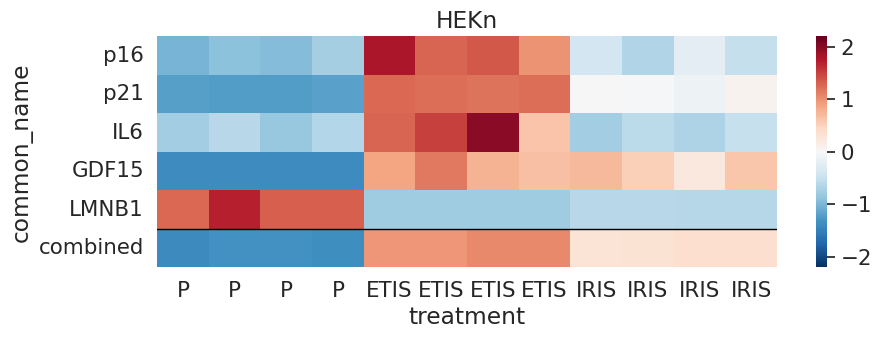

In [317]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# heatmap
sns.set(font_scale=0.5)
plt.figure(figsize=(10, 3))

# sort columns in bj_markers
bj_markers = bj_markers[["p16", "p21", "IL6", "GDF15", "LMNB1", "combined"]]

# scale colormap so middle is at value 0
vcenter = 0
vmin = -2.2
vmax = 2.2
normalize = mcolors.TwoSlopeNorm(vcenter=vcenter, vmin=vmin, vmax=vmax)
colormap = cm.RdBu_r

sns.set(font_scale=1.4)
sns.heatmap(bj_markers.T, cmap=colormap, norm=normalize, yticklabels=bj_markers.columns, xticklabels=bj_markers.index)

# draw a line before last row
plt.axhline(y=bj_markers.shape[1]-1, color='black', linewidth=1)

plt.title(celltype)
